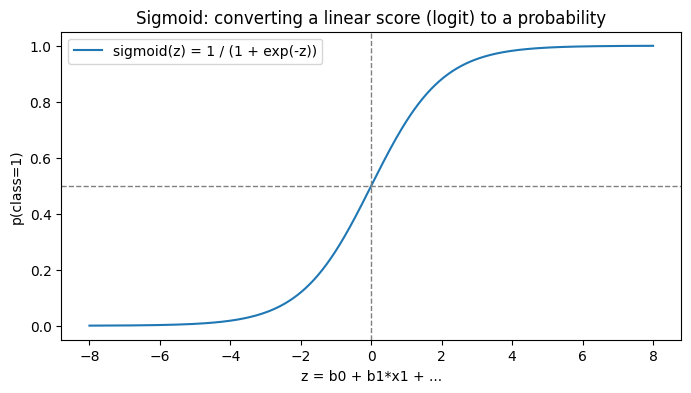

threshold=0.3 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 1 1 1 1]
threshold=0.5 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 0 1 1 1]
threshold=0.7 -> proba=[0.12 0.49 0.5  0.73 0.91] -> pred=[0 0 0 1 1]


In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Visualize the sigmoid and how thresholds map probabilities -> classes
z = np.linspace(-8, 8, 400)
sigmoid = 1 / (1 + np.exp(-z))
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid, label="sigmoid(z) = 1 / (1 + exp(-z))")
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1)
plt.axvline(0.0, color="gray", linestyle="--", linewidth=1)
plt.title("Sigmoid: converting a linear score (logit) to a probability")
plt.xlabel("z = b0 + b1*x1 + ...")
plt.ylabel("p(class=1)")
plt.ylim(-0.05, 1.05)
plt.legend()
plt.show()
# Example: turning probabilities into hard class predictions via a threshold
example_proba = np.array([0.12, 0.49, 0.50, 0.73, 0.91])
for t in [0.3, 0.5, 0.7]:
    preds = (example_proba >= t).astype(int)
    print(f"threshold={t:.1f} -> proba={example_proba} -> pred={preds}")

In [2]:
# --- Import necessary numerical and data manipulation libraries ---
import numpy as np             # NumPy for fast array and mathematical operations
import pandas as pd            # Pandas for handling tabular data (DataFrames)
import matplotlib.pyplot as plt  # Matplotlib for generating plots and charts
# Import display function to format outputs beautifully in Jupyter
from IPython.display import display
# --- Import scikit-learn components ---
# 1. Dataset generation
from sklearn.datasets import load_iris
# 2. Splitting data into training and test sets
from sklearn.model_selection import train_test_split
# 3. Building machine learning pipelines
from sklearn.pipeline import Pipeline
# 4. Feature scaling standardizer (mean=0, variance=1)
from sklearn.preprocessing import StandardScaler
# 5. Logistic Regression models (standard and with cross-validation)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
# 6. Evaluation metrics for classification performance
from sklearn.metrics import (
    accuracy_score,         # Overall correctness
    precision_score,        # Quality of positive predictions
    recall_score,           # Ability to find positive instances
    f1_score,               # Harmonic mean of precision and recall
    roc_auc_score,          # Area under ROC curve (distinction between classes)
    confusion_matrix,       # Matrix of true vs false predictions
    ConfusionMatrixDisplay, # Visual representation of the confusion matrix
)

In [5]:
iris=load_iris(as_frame=True)
df=iris.frame

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [8]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [13]:
df = df[df['target'].isin([0, 1])].copy()
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor'})

In [14]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
95,5.7,3.0,4.2,1.2,1,versicolor
96,5.7,2.9,4.2,1.3,1,versicolor
97,6.2,2.9,4.3,1.3,1,versicolor
98,5.1,2.5,3.0,1.1,1,versicolor


In [15]:
X_df = df.drop(columns=['target', 'species'])
y = df['target']

In [17]:
import seaborn as sns

<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

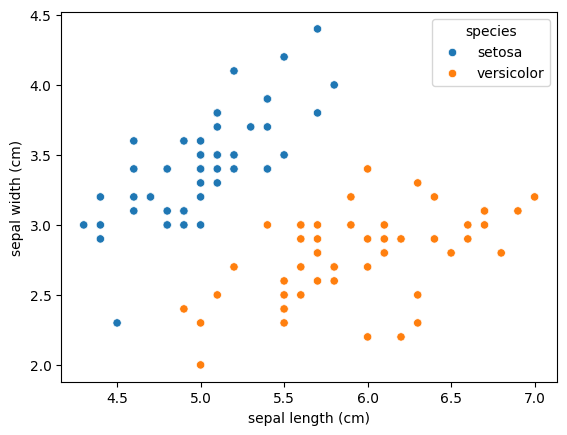

In [18]:
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species')

In [31]:
X_train, X_test, y_train, y_test = train_test_split( X_df,y, train_size=0.8, stratify=y,random_state=42)


In [32]:
majority_class = int(y_train.value_counts().idxmax())

In [33]:
majority_class

0

In [34]:
y_train


15    0
52    1
60    1
66    1
68    1
     ..
17    0
36    0
85    1
21    0
25    0
Name: target, Length: 80, dtype: int64

In [35]:
baseline_pred = np.full(shape=y_test.shape, fill_value=majority_class)
baseline_acc = accuracy_score(y_test, baseline_pred)
baseline_f1 = f1_score(y_test, baseline_pred)

In [36]:
baseline_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [37]:
print(f"Majority class (from train): {majority_class}")
print(f"Baseline Accuracy: {baseline_acc:.3f}")
print(f"Baseline F1: {baseline_f1:.3f}")

Majority class (from train): 0
Baseline Accuracy: 0.500
Baseline F1: 0.000


In [38]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 80, Test samples: 20


Test-set metrics (threshold = 0.5)
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000


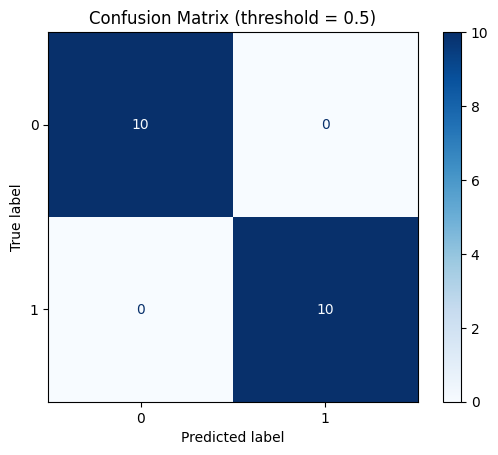

In [39]:
# Define an ML Pipeline: Data Scaling followed by Logistic Regression Training
log_reg_model = Pipeline([
    # Step 1: Standardize features (mean=0, variance=1) since Logistic Regression is sensitive to data scale
    ("scaler", StandardScaler()),
    # Step 2: Initialize the actual classification model
    (
        "logreg",
        LogisticRegression(
            max_iter=2000,  # Increase maximum iterations to ensure the optimization algorithm reliably converges
            random_state=42, # Fix the random seed to ensure results remain consistent across runs
        ),
    ),
])
# Train both the scaler and the logistic regression model on the training data
log_reg_model.fit(X_train, y_train)
# Step 3: Run the trained model against the unseen test data
# Logistic Regression natively predicts probabilities between 0 and 1.
# predict_proba() returns probabilities for [Class 0, Class 1]. We slice [:, 1] to grab only Class 1 probabilities.
y_proba = log_reg_model.predict_proba(X_test)[:, 1]
# y_proba_0 = log_reg_model.predict_proba(X_test)[:, 0]
# model.predict() always strictly uses 0.5 as its hardcoded threshold.
# To assign a custom threshold, we apply logic directly against the probabilities.
# For example, we'll use a standard 0.5 threshold here just like predict() does:
chosen_threshold = 0.5
y_pred = (y_proba >= chosen_threshold).astype(int)
# Step 4: Calculate evaluation metrics based on predictions vs true labels
acc = accuracy_score(y_test, y_pred)       # Fraction of predictions that were completely correct
prec = precision_score(y_test, y_pred)     # Out of all predicted class 1s, what fraction were actually class 1
rec = recall_score(y_test, y_pred)         # Out of all actual class 1s, what fraction were correctly detected
f1 = f1_score(y_test, y_pred)              # Harmonic balance combining Precision and Recall
roc_auc = roc_auc_score(y_test, y_proba)   # Area under curve measuring class separability
# Print evaluated results
print("Test-set metrics (threshold = 0.5)")
print(f"Accuracy : {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall   : {rec:.3f}")
print(f"F1-score : {f1:.3f}")
print(f"ROC-AUC  : {roc_auc:.3f}")
# Generate and visually plot a Confusion Matrix to break down correct predictions and mistakes
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix (threshold = 0.5)")
plt.show()

In [40]:
# Define a list of test boundary rules (Decision Thresholds) to experiment with
thresholds = [0.3, 0.5, 0.7]
# Create an empty list to capture metric results over different iterations
rows = []
# Loop through each configured threshold boundary
for t in thresholds:
    # Step 1: Force prediction to 1 if confidence score >= current threshold, else 0
    pred_t = (y_proba >= t).astype(int)
    
    # Step 2: Assemble calculated metrics into a dictionary
    rows.append(
        {
            "threshold": t,
            "accuracy": accuracy_score(y_test, pred_t),
            "precision": precision_score(y_test, pred_t, zero_division=0), # Avoid dividing by zero error return 0 if undefined
            "recall": recall_score(y_test, pred_t, zero_division=0),
            "f1": f1_score(y_test, pred_t),
        }
    )
# Step 3: Compile dictionaries into a DataFrame to present neatly aligned results
threshold_df = pd.DataFrame(rows)
# Render the table highlighting the tradeoff changes
display(threshold_df)

,threshold,accuracy,precision,recall,f1
0,0.3,1.0,1.0,1.0,1.0
1,0.5,1.0,1.0,1.0,1.0
2,0.7,1.0,1.0,1.0,1.0
